#  🍄 SUSTAIN 🍄
### A Practical Example
Inspired by the famous edible-mushroom problem, we aim to solve it using technology from the 80s! I this notebook
we are trying to classify the mushrooms based on their features.

Big shootout for the creators of the dataset: https://archive.ics.uci.edu/dataset/73/mushroom !

### (1) Preprocessing
We will load the dataset and then encode a few chosen features of mushrooms as vectors.


In [12]:
import numpy as np
import pandas as pd
import os

In [2]:
print(f"working dir: {os.getcwd()}")

working dir: C:\Users\kalus\PycharmProjects\SUSTAIN-replication\notebooks


In [3]:
df = pd.read_csv("datasets/mushrooms.csv", sep=",", encoding="utf-8")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [4]:
# the most important variables are class
df.sample(4)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
7093,p,f,s,n,f,f,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l
3507,e,x,f,g,t,n,f,c,b,n,...,s,p,w,p,w,o,p,k,v,d
5653,e,x,y,n,t,n,f,c,b,e,...,s,e,e,p,w,t,e,w,c,w
2444,e,x,y,n,t,n,f,c,b,u,...,s,w,p,p,w,o,p,k,v,d


What we have to do now is to transform the output into the list readable for SUSTAIN.

### (2) Encoding
Now, we need to encode the stimuli as vectors suitable for SUSTAIN.

In [5]:
from importlib import reload
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
data_encoded = encoder.fit_transform(df).astype(int).tolist()

# 70/30 split
split_index = int(len(df) * 0.7)
train_encoded_stimuli = data_encoded[:split_index]
test_encoded_stimuli = data_encoded[split_index:]

We must combine the dim_sizes. Why? SUSTAIN internal weights are built expecting up to n values. Thus, different dimensions are not a problem when working with lower dimensions than expected. However, they are a huge problem when working with higher dimensions than expected (e.g. when the train set has fewer dimensions than the test set).

In [6]:
dim_sizes_combined = [len(categories) for categories in encoder.categories_]
print(len(test_encoded_stimuli))
print(f"dim_sizes_combined: {dim_sizes_combined}")

2438
dim_sizes_combined: [2, 6, 4, 10, 2, 9, 2, 2, 2, 12, 2, 5, 4, 4, 9, 9, 1, 4, 3, 5, 9, 6, 7]


### (3) Test run
Let's see how SUSTAIN actually performs. We are going to run it in the following fashion: first let's SUSTAIN in supervised mode first in order to train its prediction of a given class: poisonous/nonpoinsoneuss.

In [7]:
from importlib import reload
from src.sustain import SUSTAIN

# initialize the model
model = SUSTAIN(r=2.844642,
                beta=2.386305,
                d=12.0,
                eta=0.09361126,
                supervised=True,
                queried_dim=0)

model.reset(dim_sizes=dim_sizes_combined)

queried_dim = 0 # poisonous/edible

# train the model
for i, stimulus in enumerate(train_encoded_stimuli):
    res = model.present_stimulus(stimulus, queried_dim=0)


index = []
response = []
probability = []
correct = []
n_clusters = []

# test the model
for i, stimulus in enumerate(test_encoded_stimuli):
    stim_masked = list(stimulus)

    # rue target label for the test stimulus
    target_val = stim_masked[queried_dim]

    # mask the target dimension
    stim_masked[queried_dim] = -1
    probs = model.predict(stim_masked, queried_dim=queried_dim)
    pred = int(np.argmax(probs))
    is_correct = (pred == target_val)
    index.append(i)
    response.append(pred)
    probability.append(probs)
    correct.append(is_correct)
    n_clusters.append(model.n_clusters)


results_single_run = pd.DataFrame({
    "index": index,
    "response": response,
    "probability": probability,
    "correct": correct,
    "n_clusters": n_clusters,
})
results_single_run.set_index("index", inplace=True)

In [8]:
count_true  = (results_single_run["correct"] == True).sum()
count_false = (results_single_run["correct"] == False).sum()

true_positive = ((results_single_run["correct"] == True) & (results_single_run["response"] == 1)).sum()
true_negative = ((results_single_run["correct"] == True) & (results_single_run["response"] == 0)).sum()
false_positive = ((results_single_run["correct"] == False) & (results_single_run["response"] == 1)).sum()
false_negative = ((results_single_run["correct"] == False) & (results_single_run["response"] == 0)).sum()

accuracy  = round(count_true / (count_false + count_true), 3)
precision = round(true_positive / (true_positive + false_positive), 3) if (true_positive + false_positive) > 0 else 0.0
recall = round(true_positive / (true_positive + false_negative), 3) if (true_positive + false_negative) > 0 else 0.0
f1 = round(2 * (precision * recall) / (precision + recall), 3)  if (precision + recall) > 0 else 0.0

print(f"True positive: {true_positive}")
print(f"True negative: {true_negative}")
print(f"False positive: {false_positive}")
print(f"False negative: {false_negative}\n")


print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")

True positive: 1820
True negative: 274
False positive: 336
False negative: 8

Accuracy: 0.859
Precision: 0.844
Recall: 0.996
F1: 0.914


It's a good time to visuzalize the results.

### (4) Repeated testing
Now we will repeat the procedure a houndres times to make our results more stable.



In [13]:
accuracy_collection = []
precision_collection = []
recall_collection = []
f1_collection = []

# take a random subset of the dataset
df = pd.read_csv("datasets/mushrooms.csv", sep=",", encoding="utf-8")
trails = [i for i in range(100)]
for i in trails:
    df_sample = df.sample(1000)

    # encode
    encoder = OrdinalEncoder()
    data_encoded = encoder.fit_transform(df_sample).astype(int).tolist()

    # split
    split_index = int(len(df_sample) * 0.7)
    train_encoded_stimuli = data_encoded[:split_index]
    test_encoded_stimuli = data_encoded[split_index:]


    dim_sizes_combined = [len(categories) for categories in encoder.categories_]

    # initialize the model
    model = SUSTAIN(r=2.844642,
                    beta=2.386305,
                    d=12.0,
                    eta=0.09361126,
                    supervised=True,
                    queried_dim=0)

    model.reset(dim_sizes=dim_sizes_combined)

    queried_dim = 0 # poisonous/edible

    # train the model
    for i, stimulus in enumerate(train_encoded_stimuli):
        res = model.present_stimulus(stimulus, queried_dim=0)


    index = []
    response = []
    probability = []
    correct = []
    n_clusters = []

    # test the model
    for i, stimulus in enumerate(test_encoded_stimuli):
        stim_masked = list(stimulus)

        # rue target label for the test stimulus
        target_val = stim_masked[queried_dim]

        # mask the target dimension
        stim_masked[queried_dim] = -1
        probs = model.predict(stim_masked, queried_dim=queried_dim)
        pred = int(np.argmax(probs))
        is_correct = (pred == target_val)

        index.append(i)
        response.append(pred)
        probability.append(probs)
        correct.append(is_correct)
        n_clusters.append(model.n_clusters)


    results = pd.DataFrame({
        "index": index,
        "response": response,
        "probability": probability,
        "correct": correct,
        "n_clusters": n_clusters,
    })
    results.set_index("index", inplace=True)

    # compute stats (as above)
    count_true  = (results["correct"] == True).sum()
    count_false = (results["correct"] == False).sum()

    true_positive = ((results["correct"] == True) & (results["response"] == 1)).sum()
    true_negative = ((results["correct"] == True) & (results["response"] == 0)).sum()
    false_positive = ((results["correct"] == False) & (results["response"] == 1)).sum()
    false_negative = ((results["correct"] == False) & (results["response"] == 0)).sum()

    accuracy  = round(count_true / (count_false + count_true), 3)
    precision = round(true_positive / (true_positive + false_positive), 3) if (true_positive + false_positive) > 0 else 0.0
    recall = round(true_positive / (true_positive + false_negative), 3) if (true_positive + false_negative) > 0 else 0.0
    f1 = round(2 * (precision * recall) / (precision + recall), 3)  if (precision + recall) > 0 else 0.0

    # append the results
    accuracy_collection.append(accuracy)
    precision_collection.append(precision)
    recall_collection.append(recall)
    f1_collection.append(f1)

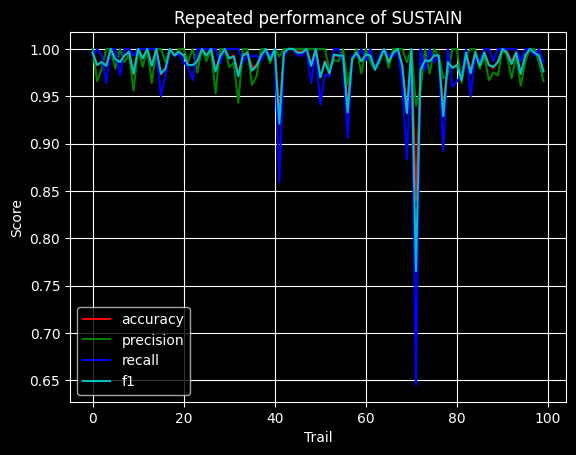

In [14]:
from matplotlib import pyplot as plt


plt.plot(trails, accuracy_collection, color='r', label='accuracy')
plt.plot(trails, precision_collection, color='g', label='precision')
plt.plot(trails, recall_collection, color='b', label='recall')
plt.plot(trails, f1_collection, color='c', label='f1')

plt.xlabel("Trail")
plt.ylabel("Score")
plt.title("Repeated performance of SUSTAIN")
plt.grid(True)
plt.legend()
plt.show()

In [15]:
import numpy as np
print(f"Mean Accuracy: {round(np.mean(accuracy_collection), 2)}")
print(f"Accuracy SD: {round(np.std(accuracy_collection), 2)}")
print(f"Mean Precision: {round(np.mean(precision_collection), 2)}")
print(f"Precision SD: {round(np.std(precision_collection), 2)}")
print(f"Mean Recall: {round(np.mean(recall_collection), 2)}")
print(f"Recall SD: {round(np.std(recall_collection), 2)}")
print(f"Mean F1: {round(np.mean(f1_collection), 2)}")
print(f"F1 SD: {round(np.std(f1_collection), 2)}")

Mean Accuracy: 0.99
Accuracy SD: 0.02
Mean Precision: 0.99
Precision SD: 0.01
Mean Recall: 0.98
Recall SD: 0.04
Mean F1: 0.98
F1 SD: 0.03
